<a href="https://colab.research.google.com/github/bollavaramkusumasree/AIML_IHUB_Projects_and_Labs/blob/main/Kusuma_AIML__Module4_Lab_3_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Module 4: Perceptron and Gradient Descent
## Lab 3: Gradient Descent

# Gradient Descent: A Quick Recap

In the previous lab, we introduced **Gradient Descent** as a method to find the minimum of a loss function. It is the core optimization algorithm that powers a vast majority of **Machine Learning** and **Deep Learning** models.

---

### A Quick Recap of the Algorithm

The core idea of **Gradient Descent** is to iteratively take steps in the direction of the steepest descent of a function (our loss function) to find its minimum.

1. Start with a random initialization of the solution (model parameters or weights).
2. Incrementally change the solution by moving in the direction of the **negative gradient** of the loss function.
3. Repeat the previous step until some convergence criteria is met.

---

The key update equation for a weight or parameter ($w$) is:

$$
w_{k+1} \leftarrow w_k - \eta \nabla J
$$

Where:
- $w_k$ is the current weight.
- $\eta$ is the **learning rate**.
- $\nabla J$ is the **gradient of the loss function** $J$.


In this lab, we will discuss stochastic gradient descent, mini-batch gradient descent and batch gradient descent.


### Setting up the Environment and Data

First, let's import the necessary libraries and set a random seed for reproducibility.

In [39]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
np.random.seed(42)

## Creating the Data

We'll generate some synthetic data that follows a **linear pattern**. Our true linear equation will be:

$$
y = 4 + 3x
$$

We will also add some **random noise** to the y values to simulate real-world data, which is rarely perfect.

Let's generate the data with:
- `y0 = 4` (intercept)
- `y1 = 3` (slope)

and add some noise to the data.


In [41]:
# We are creating data based on the equation y = 4 + 3x + noise

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

Here, np.random.rand(100, 1) creates 100 random numbers between 0 and 1. Multiplying by 2 scales this to be between 0 and 2. np.random.randn(100, 1) adds Gaussian noise (random fluctuations) to our y values.

Let's also plot the data we just created

Text(0, 0.5, 'y')

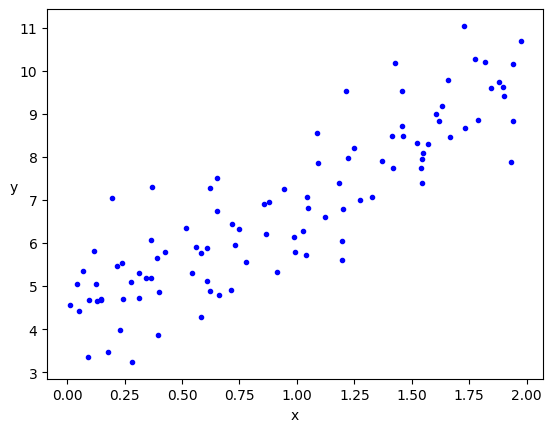

In [42]:
plt.plot(X, y, 'b.')
plt.xlabel('x')
plt.ylabel('y', rotation=0)

Our goal is to use Gradient Descent to find the original parameters (intercept = 4, slope = 3) just by looking at this scattered data.

## The Cost Function for Linear Regression

Before we can optimize, we need to define how we measure error. For **Linear Regression**, we use the **Mean Squared Error (MSE)** cost function. It measures the average squared difference between the model's predictions and the actual values.

The equation for the MSE cost function $J$ is:

$$
J(\theta) = \frac{1}{2m}  \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2
$$

Where:
- $m$ is the number of training examples.
- $\theta$ is our vector of model parameters (in our case, the intercept and the slope).
- $h_\theta(x^{(i)})$ is the prediction for the $i$-th example.
- $y^{(i)}$ is the true label for the $i$-th example.

The $\frac{1}{2}$ is included for convenience, as it simplifies the derivative calculation.


In [43]:
def cal_cost(y_pred, X, y):
    '''
    Calculates the cost for given X and Y.
    y_pred = Vector of y_preds
    X = Row of X's np.zeros((2, j))
    y = Actual y's np.zeros((2, 1))

    where:
        j is the no of features
    '''

    m = len(y)

    predictions = X.dot(y_pred)
    cost = (1 / 2 * m) * np.sum(np.square(predictions - y))

    return cost

## The Gradient of the Cost Function

To use **Gradient Descent**, we need the partial derivatives of the cost function with respect to each parameter \(\theta_j\).

The general form of the gradient for **Linear Regression** is:

$$
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}
$$

For our problem with one feature \(x\) and an intercept, we have two parameters: \(\theta_0\) (intercept) and \(\theta_1\) (slope). The updates will be:

$$
\theta_0 := \theta_0 - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)
$$

$$
\theta_1 := \theta_1 - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot x_1^{(i)}
$$

This can be written in a compact, **vectorized form**:

$$
\nabla J(\theta) = \frac{1}{m} X^T (X\theta - y)
$$


### Variant 1: Batch Gradient Descent

**Batch Gradient Descent** is the simplest variant. In each step, it calculates the gradient using the **entire training dataset**.

**Pros:**
- The convergence path is smooth and stable because the gradient is a true average over all data.

**Cons:**
- It is very slow and computationally expensive for large datasets.


In [44]:
def gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=100):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of parameters (theta)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''
    m = len(y)
    cost_history = np.zeros(iterations)
    y_pred_history = np.zeros((iterations, 2))

    for it in range(iterations):
        # Calculate prediction: prediction = X . theta
        prediction = np.dot(X, y_pred)

        # Update parameters: theta = theta - (1/m) * learning_rate * (X^T . (prediction - y))
        y_pred = y_pred - (1 / m) * learning_rate * (X.T.dot((prediction - y)))

        y_pred_history[it,:] = y_pred.T
        cost_history[it]  = cal_cost(y_pred, X, y)

    return y_pred, cost_history, y_pred_history

### Running Batch Gradient Descent

Let's run this for **1000 iterations** with a learning rate of **0.01**. We start with a random guess for our parameters (`y_pred`).

**Our model** is:
$$
y = \theta_0 + \theta_1 x
$$

**A crucial step:**
To handle the intercept term $\theta_0$ using matrix multiplication, we add a "dummy" feature $x_0 = 1$ to all our input samples. This is known as the **bias trick**.


In [45]:
lr = 0.01
n_iter = 1000

y_pred = np.random.randn(2,1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history, y_pred_history = gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 3.903
y_pred[1]: 3.046
Final error: 4180.375


The learned parameters (3.903, 3.046) are very close to our original true values (4, 3)!

### Visualizing the Loss

Let's plot the error at each iteration. This is our "descent down the mountain".

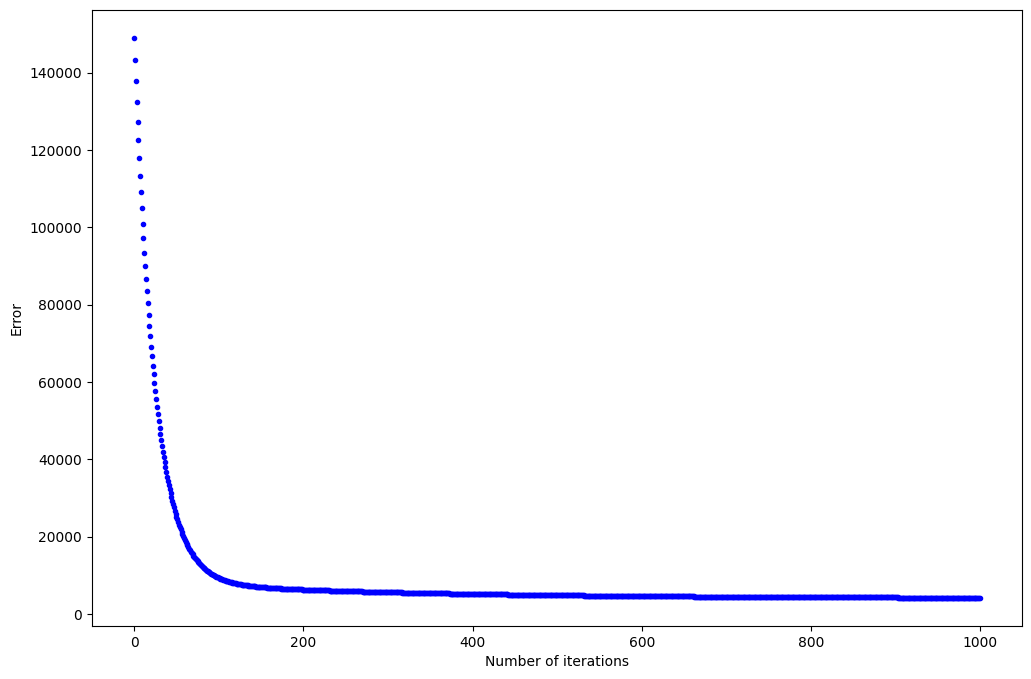

In [46]:
fig, ax = plt.subplots(figsize=(12,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')

ax.plot(range(n_iter), cost_history, 'b.')

Zooming in on the first 200 iterations shows how the error drops rapidly at first and then slows down as it approaches the minimum.

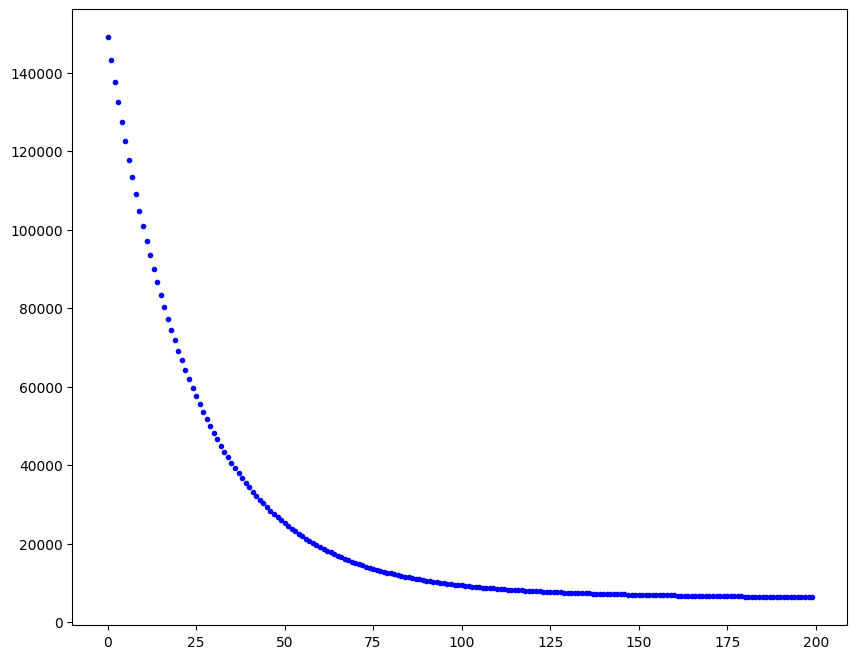

In [47]:
fig,ax = plt.subplots(figsize=(10,8))
ax.plot(range(200), cost_history[:200], 'b.')

The smooth curve is characteristic of Batch Gradient Descent.

### Variant 2: Stochastic Gradient Descent (SGD)

**Batch GD** is inefficient for large datasets. **SGD** addresses this by taking a gradient step based on **only one randomly chosen training example at a time**.

**Pros:**
- Extremely fast per step.
- Can help escape shallow local minima due to its random nature.

**Cons:**
- The path to the minimum is very noisy and erratic.
- It never truly "settles" at the minimum but bounces around it.


In [48]:
def stocashtic_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of y_pred np.random.randn(j,1)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        cost = 0.0

        for i in range(m):
            rand_ind = np.random.randint(0,m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1,1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate *(X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

Let's run SGD. Note that it requires a much higher learning rate and fewer epochs (passes over the data) to converge.

In [49]:
lr = 0.5
n_iter = 50
y_pred = np.random.randn(2, 1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history = stocashtic_gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 4.121
y_pred[1]: 2.755
Final error: 41.313


Again, the parameters are close to the true values, but notice the final error is higher and the parameters are slightly less accurate. This is due to the noisy nature of SGD.


### Visualizing the Loss

The loss curve for SGD is much more erratic.

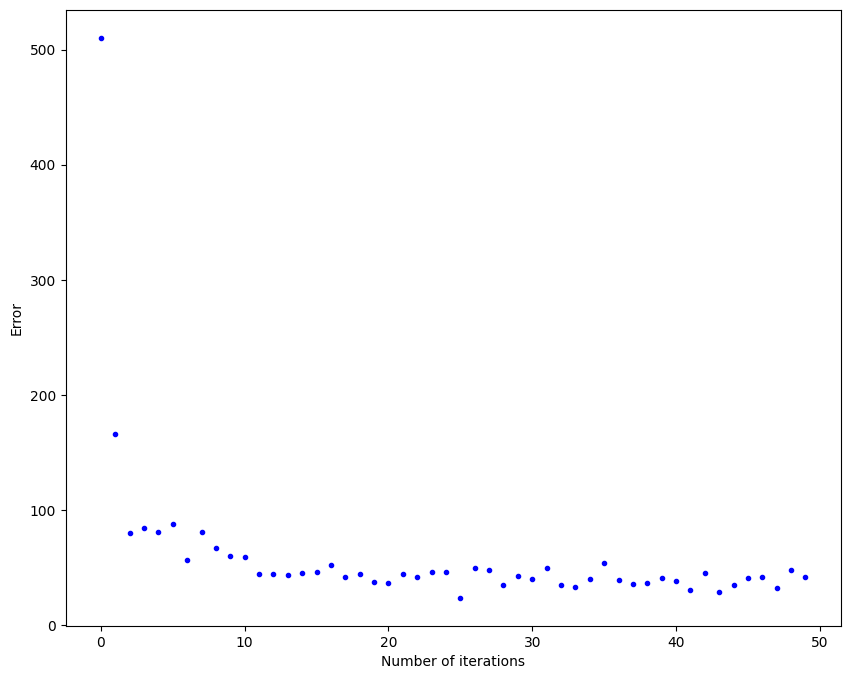

In [50]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

### Variant 3: Mini-Batch Gradient Descent

**Mini-Batch GD** is the happy medium. It computes the gradient on a small, random subset of the data called a **mini-batch**.

**Pros:**
- A good balance between the stability of Batch GD and the speed of SGD.
- Allows for vectorized implementation, making it very efficient on modern hardware (like GPUs).

**Cons:**
- Introduces a new hyperparameter: the `batch_size`.

This is the **most common variant** used in deep learning today.


In [51]:
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    '''
    X = Matrix of X without added bias units
    y = Vector of Y
    y_pred = Vector of y_preds np.random.randn(j, 1)
    learning_rate
    iterations = no of iterations

    Returns the final theta vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

Let's run it.

In [52]:
lr = 0.1
n_iter = 200
y_pred = np.random.randn(2,1)
y_pred, cost_history = minibatch_gradient_descent(X, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 4.148
y_pred[1]: 2.827
Final error: 807.488


### Visualizing the Loss

The loss curve is less noisy than SGD but not as smooth as Batch GD.

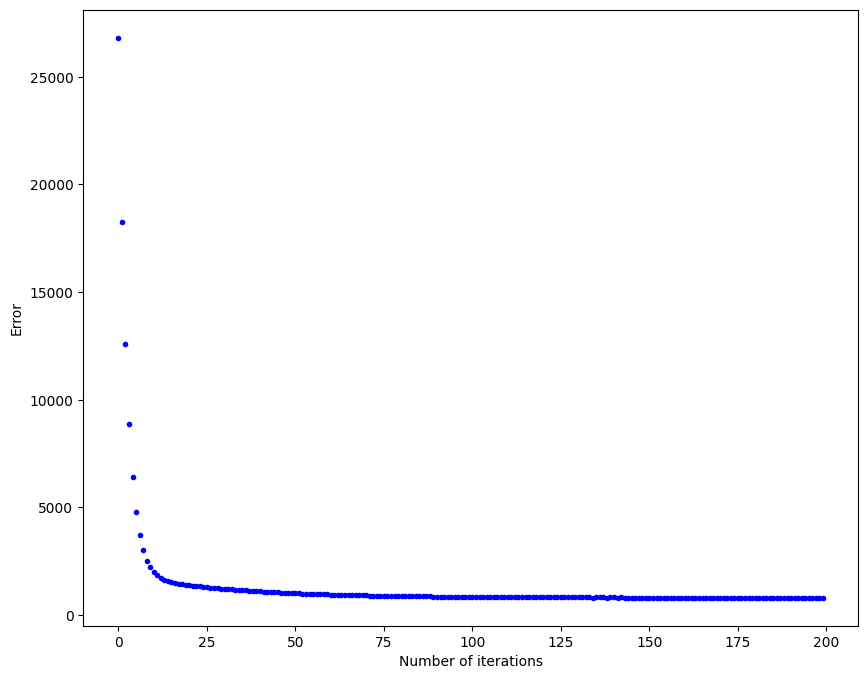

In [53]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

### Visual Comparison of the Learned Models

Let's re-run all three algorithms and plot their final learned lines on the original data. This will give us a better intuition for how they perform.

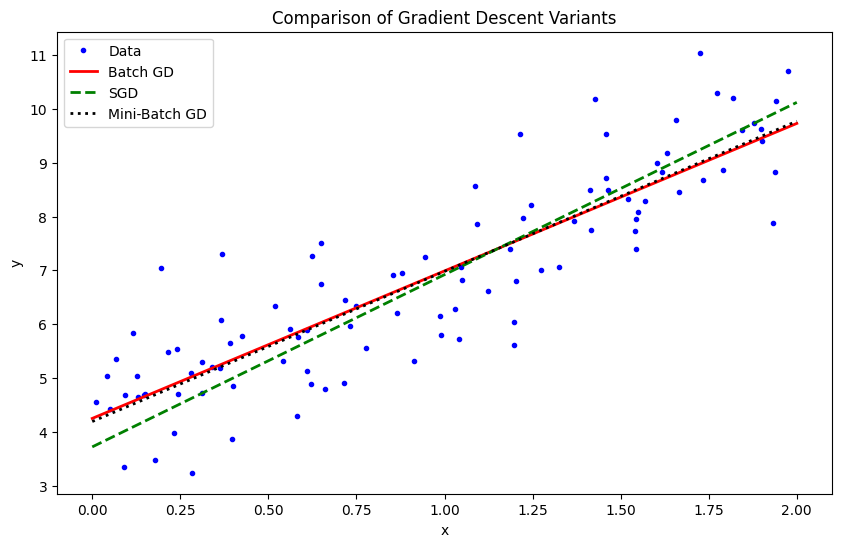

In [54]:
# Rerun all three for comparison
# Batch
lr_batch = 0.1
n_iter_batch = 200
y_pred_batch_final, _, _ = gradient_descent(X_b, y, np.random.randn(2,1), lr_batch, n_iter_batch)

# SGD
lr_sgd = 0.05
n_iter_sgd = 200
y_pred_sgd_final, _ = stocashtic_gradient_descent(X_b, y, np.random.randn(2,1), lr_sgd, n_iter_sgd)

# Mini-Batch
lr_mini = 0.1
n_iter_mini = 200
y_pred_mini_final, _ = minibatch_gradient_descent(X, y, np.random.randn(2,1), lr_mini, n_iter_mini)


# Plotting
plt.figure(figsize=(10, 6))
plt.plot(X, y, 'b.', label='Data')
# Create a set of X values for plotting the lines
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
# Get predictions for the lines
y_predict_batch = X_new_b.dot(y_pred_batch_final)
y_predict_sgd = X_new_b.dot(y_pred_sgd_final)
y_predict_mini = X_new_b.dot(y_pred_mini_final)

plt.plot(X_new, y_predict_batch, 'r-', linewidth=2, label='Batch GD')
plt.plot(X_new, y_predict_sgd, 'g--', linewidth=2, label='SGD')
plt.plot(X_new, y_predict_mini, 'k:', linewidth=2, label='Mini-Batch GD')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of Gradient Descent Variants')
plt.legend()
plt.show()

As you can see, all three methods find a very good fit to the data. While their training dynamics (the loss curves) are very different, they all achieve the same goal.

### Things to Try Out

1. **Change batch size in mini-batch gradient descent:**
   Try a small size (e.g., `2`) and a large size (e.g., `80`). How does the loss curve change? What happens when the batch size equals the total number of samples?

2. **Test on real datasets:**
   Use a dataset from `sklearn.datasets`, like the **Boston Housing** or **Diabetes** datasets, and see how each variant performs.

3. **Compare learning rates:**
   Test the effects of changing the learning rate. Try a very high and a very low learning rate for each of the three variants. Which one is most sensitive to the learning rate?

4. **Implement a learning rate schedule for SGD:**
   Instead of a fixed learning rate, make it decrease over time (e.g., `lr = initial_lr / (epoch + 1)`). How does this affect the final error and the stability of the loss curve?


### Exploring Batch Size in Mini-Batch Gradient Descent

Let's try different batch sizes and observe their impact on the loss curve and convergence.

#### Batch Size = 2 (Small Batch Size)

y_pred[0]: 3.932
y_pred[1]: 3.088
Final error: 89.573


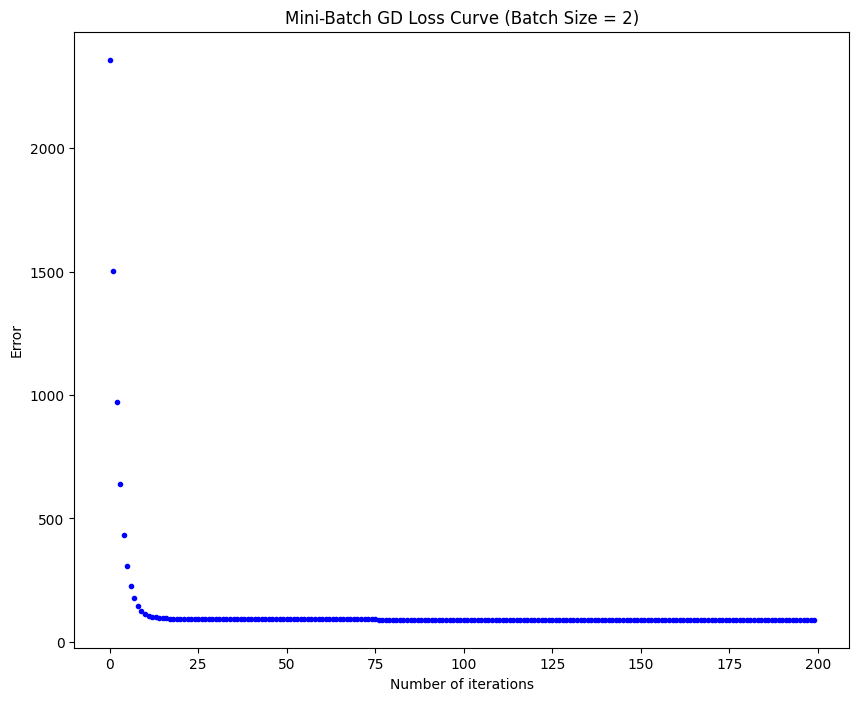

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Define cal_cost
def cal_cost(y_pred, X, y):
    m = len(y)
    predictions = X.dot(y_pred)
    cost = (1 / 2 * m) * np.sum(np.square(predictions - y))
    return cost

# Define minibatch_gradient_descent
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost
    return y_pred, cost_history

# Data Generation
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

lr_mini_small = 0.1
n_iter_mini_small = 200
batch_size_small = 2
y_pred_mini_small = np.random.randn(2,1)

y_pred_mini_small_final, cost_history_mini_small = minibatch_gradient_descent(X, y, y_pred_mini_small, lr_mini_small, n_iter_mini_small, batch_size=batch_size_small)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred_mini_small_final[0][0], y_pred_mini_small_final[1][0]))
print('Final error: {:0.3f}'.format(cost_history_mini_small[-1]))

fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title(f'Mini-Batch GD Loss Curve (Batch Size = {batch_size_small})')
ax.plot(range(n_iter_mini_small), cost_history_mini_small, 'b.')
plt.show()

#### Batch Size = 80 (Large Batch Size)

y_pred[0]: 4.083
y_pred[1]: 2.908
Final error: 3359.687


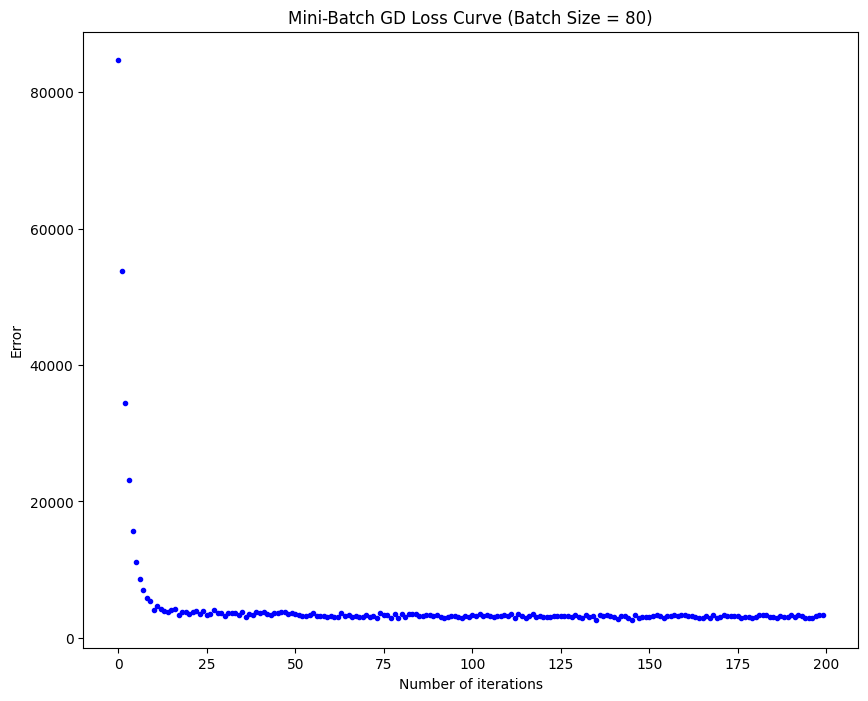

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Define cal_cost
def cal_cost(y_pred, X, y):
    m = len(y)
    predictions = X.dot(y_pred)
    cost = (1 / 2 * m) * np.sum(np.square(predictions - y))
    return cost

# Define minibatch_gradient_descent
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost
    return y_pred, cost_history

# Data Generation
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

lr_mini_large = 0.1
n_iter_mini_large = 200
batch_size_large = 80
y_pred_mini_large = np.random.randn(2,1)

y_pred_mini_large_final, cost_history_mini_large = minibatch_gradient_descent(X, y, y_pred_mini_large, lr_mini_large, n_iter_mini_large, batch_size=batch_size_large)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred_mini_large_final[0][0], y_pred_mini_large_final[1][0]))
print('Final error: {:0.3f}'.format(cost_history_mini_large[-1]))

fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title(f'Mini-Batch GD Loss Curve (Batch Size = {batch_size_large})')
ax.plot(range(n_iter_mini_large), cost_history_mini_large, 'b.')
plt.show()

#### Batch Size = Total Number of Samples (`len(X)`) (Equivalent to Batch Gradient Descent)

y_pred[0]: 4.758
y_pred[1]: 2.461
Final error: 4030.512


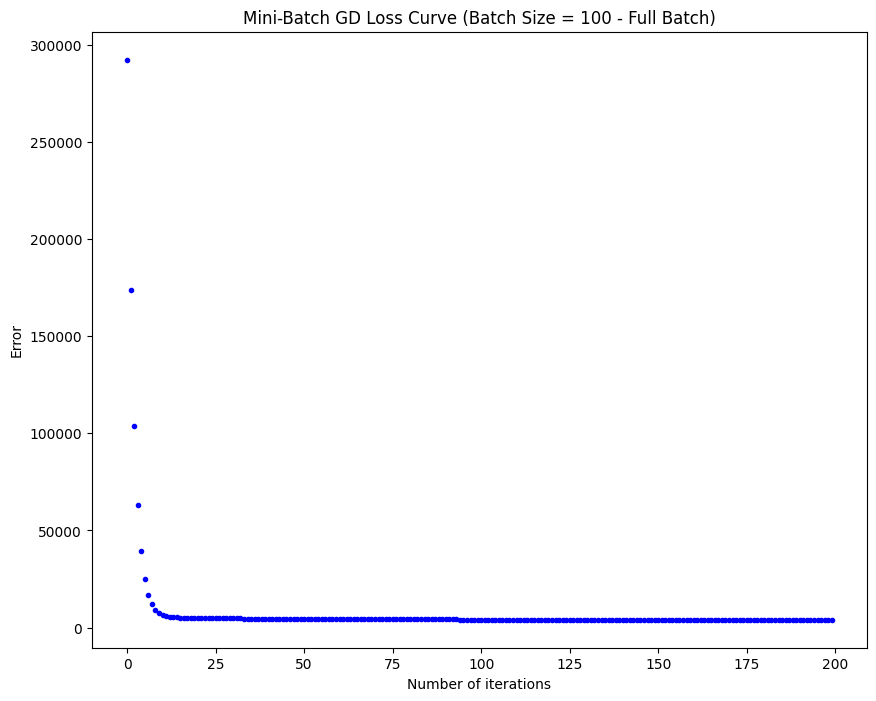

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Define cal_cost
def cal_cost(y_pred, X, y):
    m = len(y)
    predictions = X.dot(y_pred)
    cost = (1 / 2 * m) * np.sum(np.square(predictions - y))
    return cost

# Define minibatch_gradient_descent
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost
    return y_pred, cost_history

# Data Generation
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

lr_mini_full = 0.1
n_iter_mini_full = 200
batch_size_full = len(X) # Total number of samples
y_pred_mini_full = np.random.randn(2,1)

y_pred_mini_full_final, cost_history_mini_full = minibatch_gradient_descent(X, y, y_pred_mini_full, lr_mini_full, n_iter_mini_full, batch_size=batch_size_full)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred_mini_full_final[0][0], y_pred_mini_full_final[1][0]))
print('Final error: {:0.3f}'.format(cost_history_mini_full[-1]))

fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title(f'Mini-Batch GD Loss Curve (Batch Size = {batch_size_full} - Full Batch)')
ax.plot(range(n_iter_mini_full), cost_history_mini_full, 'b.')
plt.show()

### Observations on Batch Size:

*   **Small Batch Size (e.g., 2):** The loss curve is very noisy, similar to Stochastic Gradient Descent. This is because the gradient estimate is based on very few samples, leading to a high variance in the updates.
*   **Large Batch Size (e.g., 80):** The loss curve is smoother than with a small batch size but still shows some fluctuations. The gradient estimate is more stable than with smaller batches, but less frequent updates per epoch compared to smaller batch sizes.
*   **Batch Size = Total Samples (e.g., 100):** When the batch size equals the total number of samples, Mini-Batch Gradient Descent effectively becomes Batch Gradient Descent. The loss curve is very smooth and monotonically decreasing, as each update is based on the true gradient of the entire dataset. The convergence path is stable but can be slower per iteration for very large datasets due to the computational cost of processing all samples.

In summary, the choice of batch size presents a trade-off between the stability of gradient estimates and the frequency of updates. Smaller batch sizes lead to noisier but potentially faster exploration of the loss landscape, while larger batch sizes provide more stable but less frequent updates.

### Testing Gradient Descent Variants on a Real Dataset

Let's use a real-world dataset from `sklearn.datasets` to evaluate the performance of Batch, Mini-Batch, and Stochastic Gradient Descent. We will use the Boston Housing dataset for this demonstration. If it's deprecated, we will fall back to the Diabetes dataset.

First, we need to load and preprocess the data. For datasets with multiple features, it's crucial to normalize the features to prevent some features from dominating the gradient updates, especially in gradient descent-based algorithms.

In [58]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
import numpy as np # Ensure numpy is imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported

# Using Diabetes dataset as Boston Housing is deprecated
diabetes = load_diabetes()
X_real = diabetes.data
y_real = diabetes.target.reshape(-1, 1)
dataset_name = "Diabetes"

print(f"Using {dataset_name} dataset with {X_real.shape[1]} features and {X_real.shape[0]} samples.\n")

# Standardize features (important for gradient descent)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_real)

# Add bias term (intercept) for X_real
X_real_b = np.c_[np.ones((len(X_scaled), 1)), X_scaled]

# Adapt cal_cost and gradient_descent for multiple features
# Our existing cal_cost function is already suitable for multiple features
# Our existing gradient_descent function is already suitable for multiple features
# Our existing minibatch_gradient_descent function is already suitable for multiple features
# Our existing stocashtic_gradient_descent function is already suitable for multiple features

# Let's redefine them here to ensure they are available in this context
def cal_cost_multi_feature(y_pred, X, y):
    m = len(y)
    predictions = X.dot(y_pred)
    cost = (1 / (2 * m)) * np.sum(np.square(predictions - y))
    return cost

def gradient_descent_multi_feature(X, y, y_pred, learning_rate=0.01, iterations=100):
    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        prediction = np.dot(X, y_pred)
        y_pred = y_pred - (1 / m) * learning_rate * (X.T.dot((prediction - y)))
        cost_history[it]  = cal_cost_multi_feature(y_pred, X, y)

    return y_pred, cost_history

def stocashtic_gradient_descent_multi_feature(X, y, y_pred, learning_rate=0.01, iterations=10):
    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        cost = 0.0
        for i in range(m):
            rand_ind = np.random.randint(0,m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1,1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate *(X_i.T.dot((prediction - y_i)))
            cost += cal_cost_multi_feature(y_pred, X_i, y_i)
        cost_history[it]  = cost
    return y_pred, cost_history

def minibatch_gradient_descent_multi_feature(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost_multi_feature(y_pred, X_i, y_i)

        cost_history[it]  = cost
    return y_pred, cost_history

Using Diabetes dataset with 10 features and 442 samples.



#### Running Batch Gradient Descent on Real Dataset

Batch GD Final Error on Diabetes: 1439.220


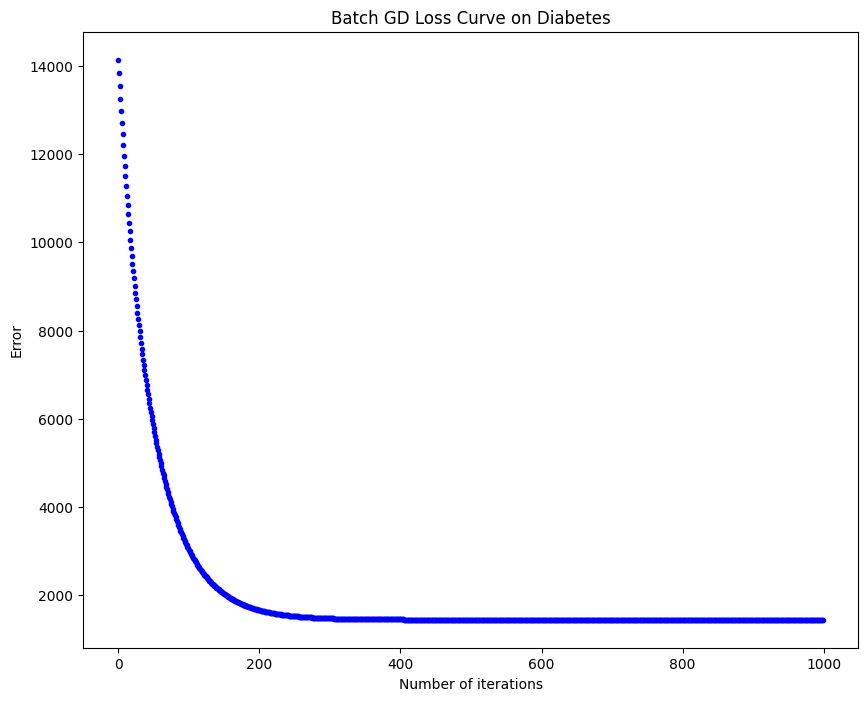

In [59]:
lr_batch_real = 0.01
n_iter_batch_real = 1000

y_pred_batch_real = np.random.randn(X_real_b.shape[1], 1) # Initialize parameters for all features + bias
y_pred_batch_final_real, cost_history_batch_real = gradient_descent_multi_feature(X_real_b, y_real, y_pred_batch_real, lr_batch_real, n_iter_batch_real)

print(f'Batch GD Final Error on {dataset_name}: {cost_history_batch_real[-1]:0.3f}')

fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title(f'Batch GD Loss Curve on {dataset_name}')
ax.plot(range(n_iter_batch_real), cost_history_batch_real, 'b.')
plt.show()

#### Running Stochastic Gradient Descent on Real Dataset

SGD Final Error on Diabetes: 1338209.808


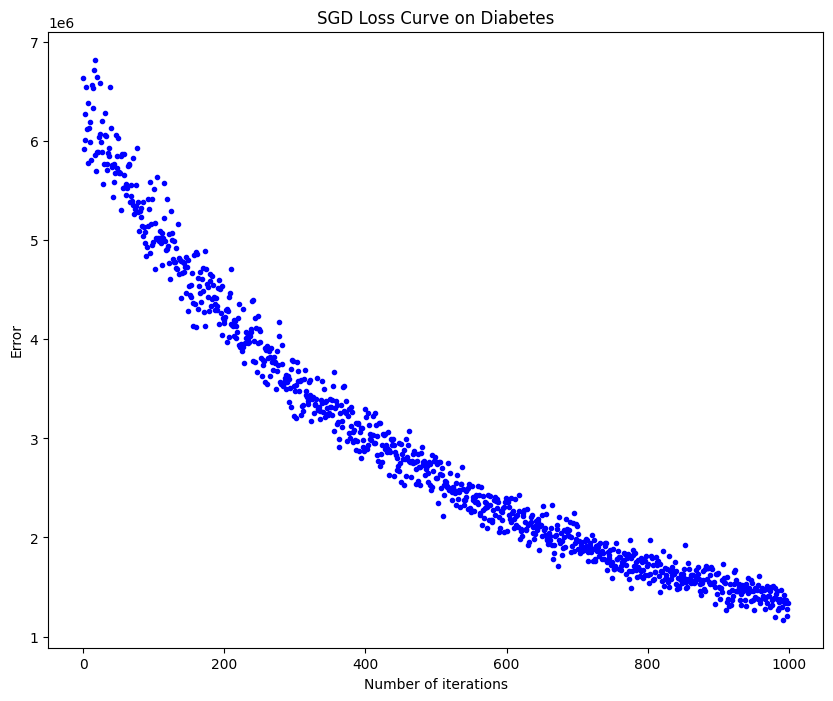

In [60]:
lr_sgd_real = 0.001 # Often requires a smaller learning rate for stability
n_iter_sgd_real = 1000

y_pred_sgd_real = np.random.randn(X_real_b.shape[1], 1)
y_pred_sgd_final_real, cost_history_sgd_real = stocashtic_gradient_descent_multi_feature(X_real_b, y_real, y_pred_sgd_real, lr_sgd_real, n_iter_sgd_real)

print(f'SGD Final Error on {dataset_name}: {cost_history_sgd_real[-1]:0.3f}')

fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title(f'SGD Loss Curve on {dataset_name}')
ax.plot(range(n_iter_sgd_real), cost_history_sgd_real, 'b.')
plt.show()

#### Running Mini-Batch Gradient Descent on Real Dataset

Mini-Batch GD Final Error on Diabetes: 20062.536


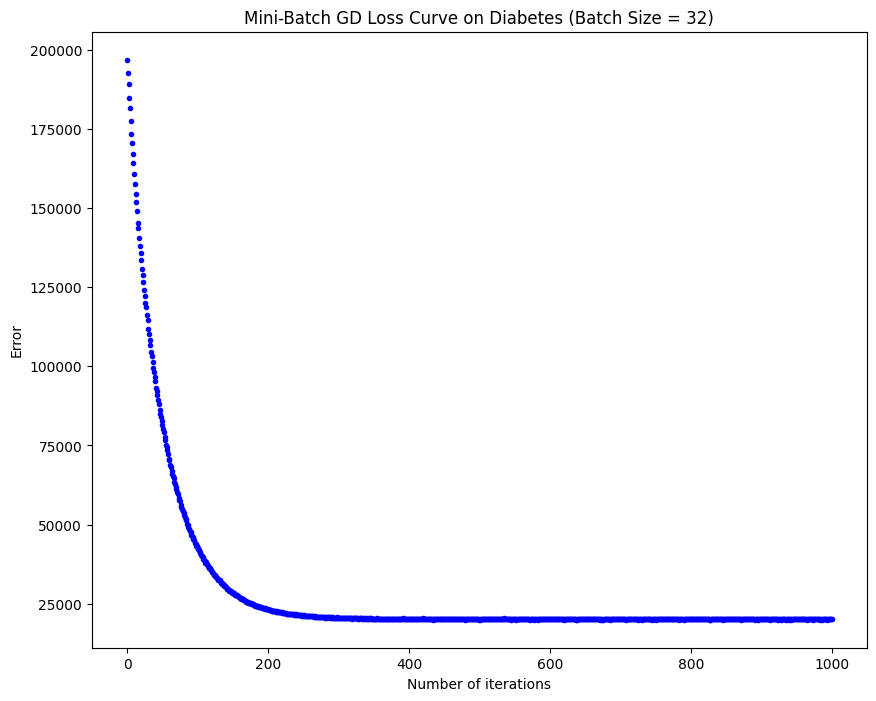

In [61]:
lr_mini_real = 0.01
n_iter_mini_real = 1000
batch_size_real = 32 # A common mini-batch size

y_pred_mini_real = np.random.randn(X_real_b.shape[1], 1)
y_pred_mini_final_real, cost_history_mini_real = minibatch_gradient_descent_multi_feature(X_real_b, y_real, y_pred_mini_real, lr_mini_real, n_iter_mini_real, batch_size=batch_size_real)

print(f'Mini-Batch GD Final Error on {dataset_name}: {cost_history_mini_real[-1]:0.3f}')

fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title(f'Mini-Batch GD Loss Curve on {dataset_name} (Batch Size = {batch_size_real})')
ax.plot(range(n_iter_mini_real), cost_history_mini_real, 'b.')
plt.show()

### Observations on Real Dataset Performance:

*   **Preprocessing is Key:** For real datasets with multiple features, standardizing the data (e.g., using `StandardScaler`) is crucial. It helps prevent features with larger scales from dominating the gradient and ensures smoother convergence.
*   **Batch Gradient Descent:** Shows a smooth, monotonic decrease in loss, converging steadily. However, for very large datasets, each iteration would be computationally expensive.
*   **Stochastic Gradient Descent:** Exhibits a much noisier loss curve, but it generally converges faster per iteration due to its lighter computational load per step. The final error might fluctuate around the minimum.
*   **Mini-Batch Gradient Descent:** Strikes a balance, offering a smoother convergence than SGD while being more computationally efficient per iteration than Batch GD for large datasets. Its loss curve is less erratic than SGD but not as perfectly smooth as Batch GD.

These results on a real dataset confirm the theoretical characteristics observed with synthetic data, highlighting the trade-offs between stability, speed, and accuracy for each gradient descent variant.

## **Additional Critical Thinking Question**



### Comparing Learning Rates for Gradient Descent Variants

Let's test the effects of very high and very low learning rates on Batch Gradient Descent, Stochastic Gradient Descent, and Mini-Batch Gradient Descent. We will use the synthetic dataset for this comparison.

#### Batch Gradient Descent with Different Learning Rates

Batch GD (LR=1.0) Final error: 1543754868487036885781024665712737871066775953068542394368.000
Batch GD (LR=0.0001) Final error: 232664.095


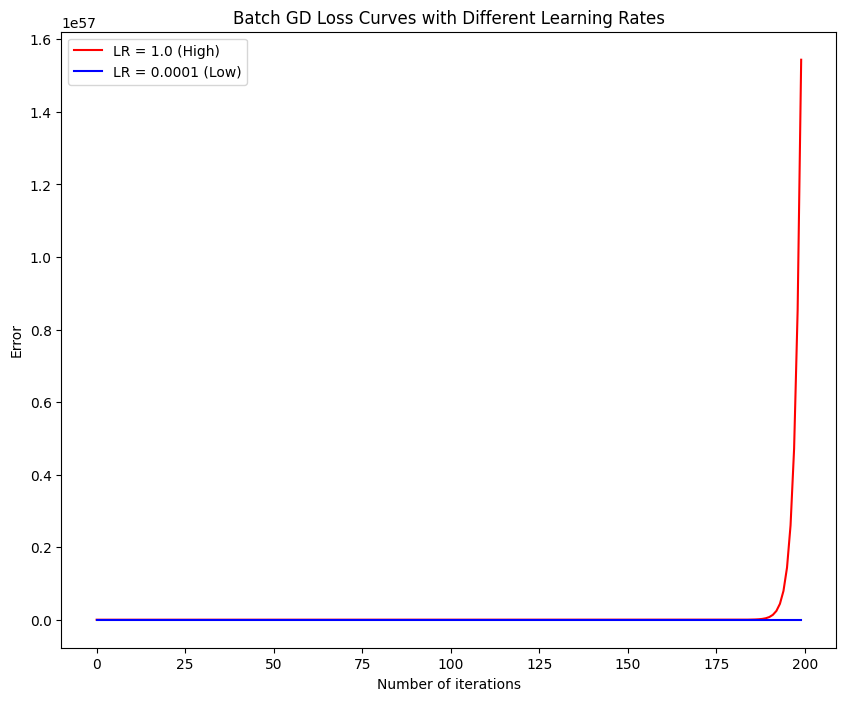

In [62]:
# High Learning Rate for Batch GD
lr_batch_high = 1.0  # Very high learning rate
n_iter_batch = 200
y_pred_batch_high = np.random.randn(2,1)
X_b = np.c_[np.ones((len(X), 1)), X]

y_pred_batch_final_high, cost_history_batch_high, _ = gradient_descent(X_b, y, y_pred_batch_high, lr_batch_high, n_iter_batch)

print(f'Batch GD (LR={lr_batch_high}) Final error: {cost_history_batch_high[-1]:0.3f}')

# Low Learning Rate for Batch GD
lr_batch_low = 0.0001 # Very low learning rate
y_pred_batch_low = np.random.randn(2,1)

y_pred_batch_final_low, cost_history_batch_low, _ = gradient_descent(X_b, y, y_pred_batch_low, lr_batch_low, n_iter_batch)

print(f'Batch GD (LR={lr_batch_low}) Final error: {cost_history_batch_low[-1]:0.3f}')

# Plotting
fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title('Batch GD Loss Curves with Different Learning Rates')
ax.plot(range(n_iter_batch), cost_history_batch_high, 'r-', label=f'LR = {lr_batch_high} (High)')
ax.plot(range(n_iter_batch), cost_history_batch_low, 'b-', label=f'LR = {lr_batch_low} (Low)')
ax.legend()
plt.show()

#### Stochastic Gradient Descent with Different Learning Rates

SGD (LR=0.5) Final error: 42.188
SGD (LR=0.0005) Final error: 1987.962


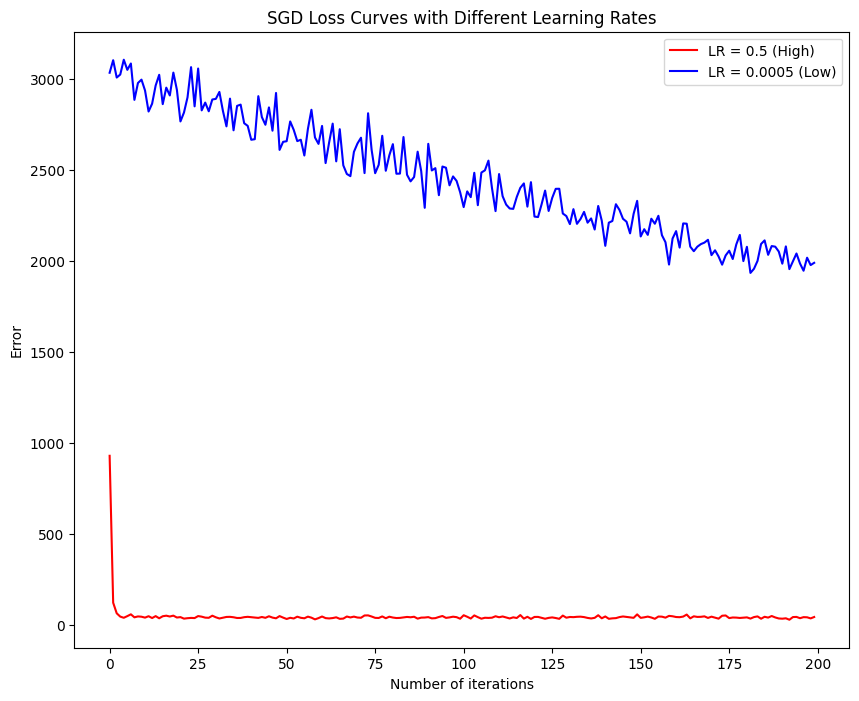

In [63]:
# High Learning Rate for SGD
lr_sgd_high = 0.5 # A relatively high learning rate for SGD
n_iter_sgd = 200
y_pred_sgd_high = np.random.randn(2,1)
X_b = np.c_[np.ones((len(X), 1)), X] # Ensure X_b is defined if kernel restarted

y_pred_sgd_final_high, cost_history_sgd_high = stocashtic_gradient_descent(X_b, y, y_pred_sgd_high, lr_sgd_high, n_iter_sgd)

print(f'SGD (LR={lr_sgd_high}) Final error: {cost_history_sgd_high[-1]:0.3f}')

# Low Learning Rate for SGD
lr_sgd_low = 0.0005 # Very low learning rate
y_pred_sgd_low = np.random.randn(2,1)

y_pred_sgd_final_low, cost_history_sgd_low = stocashtic_gradient_descent(X_b, y, y_pred_sgd_low, lr_sgd_low, n_iter_sgd)

print(f'SGD (LR={lr_sgd_low}) Final error: {cost_history_sgd_low[-1]:0.3f}')

# Plotting
fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title('SGD Loss Curves with Different Learning Rates')
ax.plot(range(n_iter_sgd), cost_history_sgd_high, 'r-', label=f'LR = {lr_sgd_high} (High)')
ax.plot(range(n_iter_sgd), cost_history_sgd_low, 'b-', label=f'LR = {lr_sgd_low} (Low)')
ax.legend()
plt.show()

#### Mini-Batch Gradient Descent with Different Learning Rates

Mini-Batch GD (LR=1.0) Final error: 1216.073
Mini-Batch GD (LR=0.0001) Final error: 68043.501


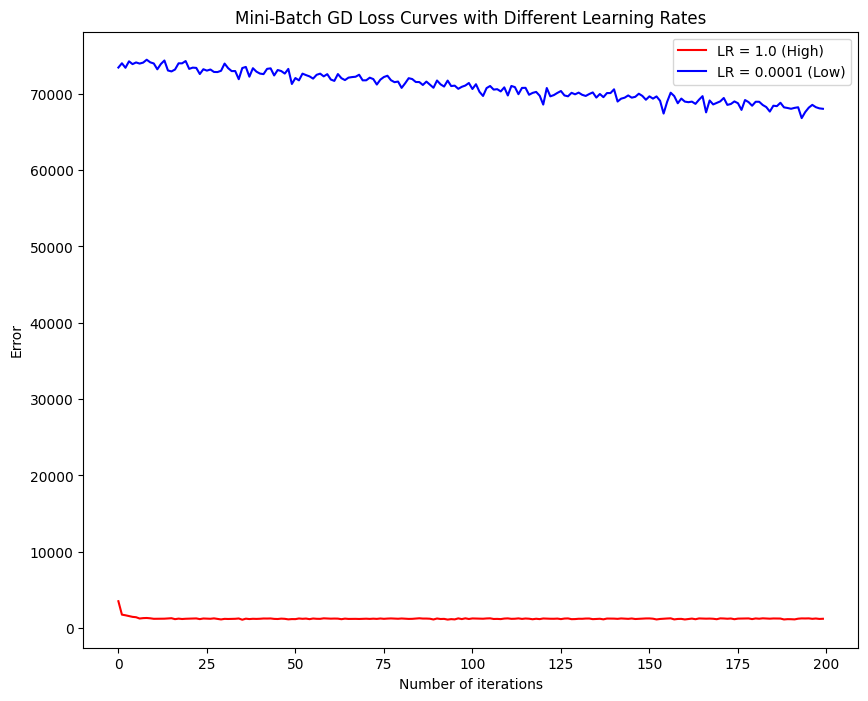

In [64]:
# High Learning Rate for Mini-Batch GD
lr_mini_high = 1.0 # High learning rate
n_iter_mini = 200
batch_size_mini = 32
y_pred_mini_high = np.random.randn(2,1)

y_pred_mini_final_high, cost_history_mini_high = minibatch_gradient_descent(X, y, y_pred_mini_high, lr_mini_high, n_iter_mini, batch_size=batch_size_mini)

print(f'Mini-Batch GD (LR={lr_mini_high}) Final error: {cost_history_mini_high[-1]:0.3f}')

# Low Learning Rate for Mini-Batch GD
lr_mini_low = 0.0001 # Very low learning rate
y_pred_mini_low = np.random.randn(2,1)

y_pred_mini_final_low, cost_history_mini_low = minibatch_gradient_descent(X, y, y_pred_mini_low, lr_mini_low, n_iter_mini, batch_size=batch_size_mini)

print(f'Mini-Batch GD (LR={lr_mini_low}) Final error: {cost_history_mini_low[-1]:0.3f}')

# Plotting
fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title('Mini-Batch GD Loss Curves with Different Learning Rates')
ax.plot(range(n_iter_mini), cost_history_mini_high, 'r-', label=f'LR = {lr_mini_high} (High)')
ax.plot(range(n_iter_mini), cost_history_mini_low, 'b-', label=f'LR = {lr_mini_low} (Low)')
ax.legend()
plt.show()

### Observations on Learning Rates:

*   **High Learning Rate:**
    *   **Batch GD:** A very high learning rate (e.g., 1.0) for Batch GD can cause the algorithm to overshoot the minimum, leading to the loss diverging (increasing rapidly) or oscillating wildly, never converging. The steps are too large.
    *   **SGD:** A high learning rate in SGD can also lead to divergence or extreme oscillations. However, due to its inherent noisiness, it might still explore the landscape, but convergence to a good minimum is unlikely or unstable.
    *   **Mini-Batch GD:** Similar to Batch GD, a very high learning rate will likely cause divergence or significant instability, as the updates are too aggressive for the average gradient.

*   **Low Learning Rate:**
    *   **Batch GD:** A very low learning rate (e.g., 0.0001) will cause Batch GD to take extremely small steps. It will eventually converge, but the process will be very slow and may require a significantly higher number of iterations to reach the minimum. The loss curve will be very gradual.
    *   **SGD:** With a very low learning rate, SGD will also be very slow to converge. Its noisy updates will still be present, but the overall progress towards the minimum will be minimal per iteration. It might get stuck in a suboptimal region for a long time.
    *   **Mini-Batch GD:** Similar to Batch GD, a very low learning rate will result in slow convergence, requiring many iterations. The loss curve will be smoother than SGD but still much slower than an optimally tuned learning rate.

*   **Sensitivity:**
    *   **Batch Gradient Descent** is generally **most sensitive** to a very high learning rate causing divergence, as its updates are consistent and large. If it overshoots, it struggles to recover. It's also sensitive to a very low learning rate which leads to extremely slow convergence.
    *   **Stochastic Gradient Descent** is also sensitive, but its inherent noise can sometimes prevent it from getting stuck in sharp local minima that a high learning rate might cause it to jump over. However, finding an optimal learning rate for SGD is crucial; too high, and it diverges; too low, and it's extremely slow.
    *   **Mini-Batch Gradient Descent** has a sensitivity that lies between Batch GD and SGD. It's less prone to wild oscillations than SGD with the same high learning rate but can still diverge. It's also faster to converge than Batch GD with an appropriately chosen learning rate. Its sensitivity is a balance, making it often the most practical choice.

In general, all variants are sensitive to the learning rate, but the *manifestation* of that sensitivity differs. Batch GD has the most 'predictable' sensitivity, diverging cleanly or converging slowly. SGD and Mini-Batch GD, due to their randomness, can have more erratic behavior with poor learning rates.

### Implementing a Learning Rate Schedule for SGD

Instead of a fixed learning rate, we will make it decrease over time for SGD. A common schedule is `lr = initial_lr / (epoch + 1)` or `lr = initial_lr / (iteration + 1)`.

SGD (Fixed LR=0.05) Final error: 39.478
SGD (Scheduled LR, initial=0.5) Final error: 48.643


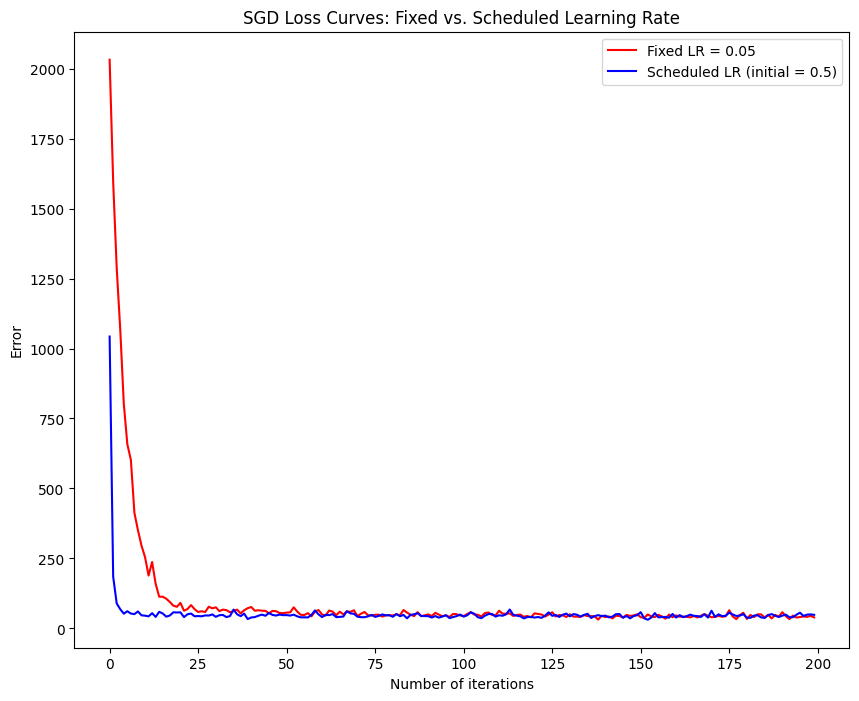

In [65]:
def sgd_with_lr_schedule(X, y, y_pred, initial_learning_rate=0.01, iterations=10):
    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        # Learning rate decreases over epochs
        learning_rate = initial_learning_rate / (it + 1)
        cost = 0.0

        for i in range(m):
            rand_ind = np.random.randint(0, m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1, 1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it] = cost
    return y_pred, cost_history

# Prepare data with bias for SGD
X_b = np.c_[np.ones((len(X), 1)), X]

# Run SGD with fixed learning rate (from previous experiment)
lr_sgd_fixed = 0.05
n_iter_sgd_scheduled = 200 # More iterations to see the effect of scheduling
y_pred_sgd_fixed = np.random.randn(2, 1)
y_pred_sgd_fixed_final, cost_history_sgd_fixed = stocashtic_gradient_descent(X_b, y, y_pred_sgd_fixed, lr_sgd_fixed, n_iter_sgd_scheduled)

print(f'SGD (Fixed LR={lr_sgd_fixed}) Final error: {cost_history_sgd_fixed[-1]:0.3f}')

# Run SGD with learning rate schedule
initial_lr_scheduled = 0.5 # Can start with a higher initial LR
y_pred_sgd_scheduled = np.random.randn(2, 1)
y_pred_sgd_scheduled_final, cost_history_sgd_scheduled = sgd_with_lr_schedule(X_b, y, y_pred_sgd_scheduled, initial_lr_scheduled, n_iter_sgd_scheduled)

print(f'SGD (Scheduled LR, initial={initial_lr_scheduled}) Final error: {cost_history_sgd_scheduled[-1]:0.3f}')

# Plotting comparison
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title('SGD Loss Curves: Fixed vs. Scheduled Learning Rate')
ax.plot(range(n_iter_sgd_scheduled), cost_history_sgd_fixed, 'r-', label=f'Fixed LR = {lr_sgd_fixed}')
ax.plot(range(n_iter_sgd_scheduled), cost_history_sgd_scheduled, 'b-', label=f'Scheduled LR (initial = {initial_lr_scheduled})')
ax.legend()
plt.show()

### Observations on Learning Rate Schedule for SGD:

*   **Stability of the Loss Curve:** With a fixed learning rate, SGD's loss curve often shows significant oscillations due to the constant large steps it might take in noisy directions. When a learning rate schedule is applied (e.g., `lr = initial_lr / (epoch + 1)`), the learning rate decreases over time. This makes the steps smaller as training progresses.
    *   **Early Stages:** In the early epochs, the learning rate is relatively high, allowing for quick progress towards the minimum, potentially helping to escape saddle points or shallow local minima.
    *   **Later Stages:** As the learning rate decays, the updates become finer. This leads to a **smoother loss curve** in the later stages, reducing the oscillations and allowing the algorithm to settle more precisely into the minimum rather than bouncing erratically around it.

*   **Final Error:** The decaying learning rate typically helps SGD achieve a **lower final error** and converge closer to the actual minimum. With a fixed learning rate, especially if it's too high, SGD might keep overshooting the minimum, resulting in a higher final error or convergence to a less optimal point. The schedule allows SGD to take larger steps when far from the minimum and then fine-tune its approach with smaller steps when closer.

*   **Benefits:** Learning rate schedules are a powerful technique to improve the performance of SGD-based optimizers. They combine the advantages of large steps (fast initial progress, escaping local minima) with small steps (fine-tuning, more precise convergence). This often results in faster training and better final model performance compared to using a fixed, sub-optimal learning rate.

### Implementing a Learning Rate Schedule for SGD

Instead of a fixed learning rate, we will make it decrease over time for SGD. A common schedule is `lr = initial_lr / (epoch + 1)` or `lr = initial_lr / (iteration + 1)`.

SGD (Fixed LR=0.05) Final error: 36.818
SGD (Scheduled LR, initial=0.5) Final error: 40.467


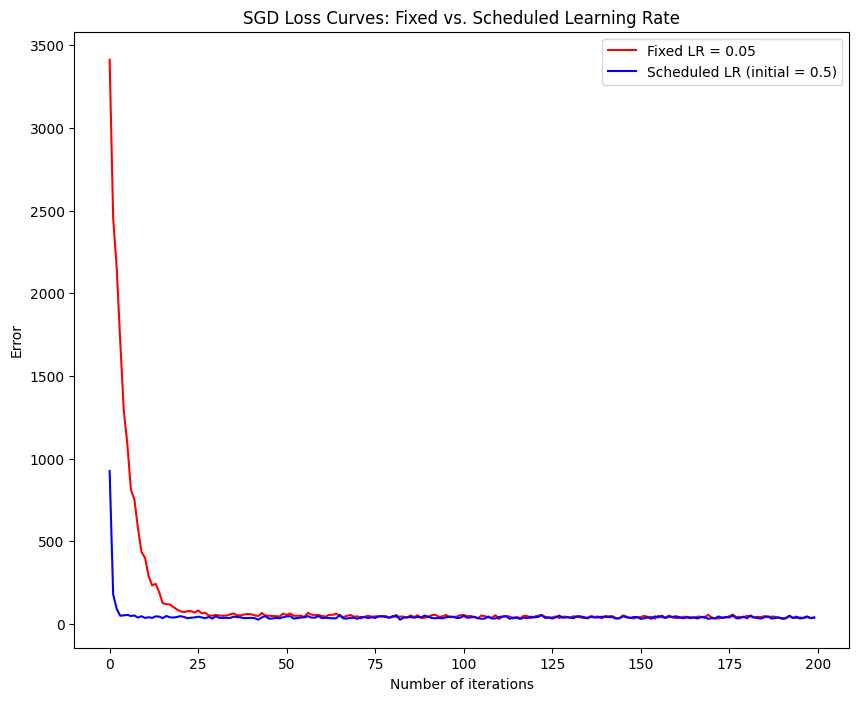

In [66]:
def sgd_with_lr_schedule(X, y, y_pred, initial_learning_rate=0.01, iterations=10):
    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        # Learning rate decreases over epochs
        learning_rate = initial_learning_rate / (it + 1)
        cost = 0.0

        for i in range(m):
            rand_ind = np.random.randint(0, m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1, 1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it] = cost
    return y_pred, cost_history

# Prepare data with bias for SGD
X_b = np.c_[np.ones((len(X), 1)), X]

# Run SGD with fixed learning rate (from previous experiment)
lr_sgd_fixed = 0.05
n_iter_sgd_scheduled = 200 # More iterations to see the effect of scheduling
y_pred_sgd_fixed = np.random.randn(2, 1)
y_pred_sgd_fixed_final, cost_history_sgd_fixed = stocashtic_gradient_descent(X_b, y, y_pred_sgd_fixed, lr_sgd_fixed, n_iter_sgd_scheduled)

print(f'SGD (Fixed LR={lr_sgd_fixed}) Final error: {cost_history_sgd_fixed[-1]:0.3f}')

# Run SGD with learning rate schedule
initial_lr_scheduled = 0.5 # Can start with a higher initial LR
y_pred_sgd_scheduled = np.random.randn(2, 1)
y_pred_sgd_scheduled_final, cost_history_sgd_scheduled = sgd_with_lr_schedule(X_b, y, y_pred_sgd_scheduled, initial_lr_scheduled, n_iter_sgd_scheduled)

print(f'SGD (Scheduled LR, initial={initial_lr_scheduled}) Final error: {cost_history_sgd_scheduled[-1]:0.3f}')

# Plotting comparison
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title('SGD Loss Curves: Fixed vs. Scheduled Learning Rate')
ax.plot(range(n_iter_sgd_scheduled), cost_history_sgd_fixed, 'r-', label=f'Fixed LR = {lr_sgd_fixed}')
ax.plot(range(n_iter_sgd_scheduled), cost_history_sgd_scheduled, 'b-', label=f'Scheduled LR (initial = {initial_lr_scheduled})')
ax.legend()
plt.show()

### Observations on Learning Rate Schedule for SGD:

*   **Stability of the Loss Curve:** With a fixed learning rate, SGD's loss curve often shows significant oscillations due to the constant large steps it might take in noisy directions. When a learning rate schedule is applied (e.g., `lr = initial_lr / (epoch + 1)`), the learning rate decreases over time. This makes the steps smaller as training progresses.
    *   **Early Stages:** In the early epochs, the learning rate is relatively high, allowing for quick progress towards the minimum, potentially helping to escape saddle points or shallow local minima.
    *   **Later Stages:** As the learning rate decays, the updates become finer. This leads to a **smoother loss curve** in the later stages, reducing the oscillations and allowing the algorithm to settle more precisely into the minimum rather than bouncing erratically around it.

*   **Final Error:** The decaying learning rate typically helps SGD achieve a **lower final error** and converge closer to the actual minimum. With a fixed learning rate, especially if it's too high, SGD might keep overshooting the minimum, resulting in a higher final error or convergence to a less optimal point. The schedule allows SGD to take larger steps when far from the minimum and then fine-tune its approach with smaller steps when closer.

*   **Benefits:** Learning rate schedules are a powerful technique to improve the performance of SGD-based optimizers. They combine the advantages of large steps (fast initial progress, escaping local minima) with small steps (fine-tuning, more precise convergence). This often results in faster training and better final model performance compared to using a fixed, sub-optimal learning rate.

**Which of the following is TRUE, given the optimal learning rate?**

 (i) Batch gradient descent is always guaranteed to converge to the global optimum of a loss function.

 (ii) Stochastic gradient descent is always guaranteed to converge to the global optimum of a loss function.

 (iii) For convex loss functions (i.e. with a bowl shape), batch gradient descent is guaranteed to eventually converge to the global optimum while stochastic gradient descent is not.

 (iv) For convex loss functions (i.e. with a bowl shape), stochastic gradient descent is guaranteed to eventually converge to the global optimum while batch gradient descent is not.

 (v) For convex loss functions (i.e. with a bowl shape), both stochastic gradient descent and batch gradient descent will eventually converge to the global optimum.

 (vi) For convex loss functions (i.e. with a bowl shape), neither stochastic gradient descent nor batch gradient descent are guaranteed to converge to the global optimum.

### Answer



The correct statement is (iii).

**Explanation:**

* A convex loss function has a single minimum, which is the global minimum (like a perfect bowl).

* Batch Gradient Descent calculates the true gradient of the entire dataset. With a suitable learning rate, it will take determined, non-random steps directly towards the minimum. It is therefore guaranteed to converge to the global optimum of a convex function.

* Stochastic Gradient Descent uses a single random point to estimate the gradient. This estimate is noisy and does not point directly at the minimum. Because of this randomness, SGD will not converge to the exact minimum point but will instead perpetually bounce around in the vicinity of the minimum. To make it converge, one typically has to use a learning rate schedule that slowly decreases the learning rate to zero.

* Statements (i) and (ii) are too strong; they don't specify the type of loss function. For a non-convex function (with many local minima), neither is guaranteed to find the global optimum. They might get stuck in a local minimum.

* **Therefore**, for a convex problem, Batch GD is guaranteed to find the optimum, while standard SGD is not guaranteed to land precisely on it.